In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from  sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [7]:
X=6*np.random.rand(200,1)-3
X.shape

(200, 1)

In [9]:
y= (0.8* X**2) + (0.9*X) + 2+ np.random.randn(200,1)
y.shape

(200, 1)

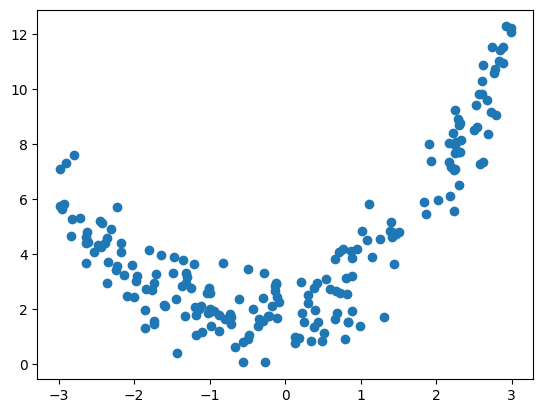

In [11]:
plt.scatter(X,y)

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [15]:
lr=LinearRegression()

In [16]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred=lr.predict(X_test)

In [19]:
r2_score(y_test,y_pred)

0.2796115505330803

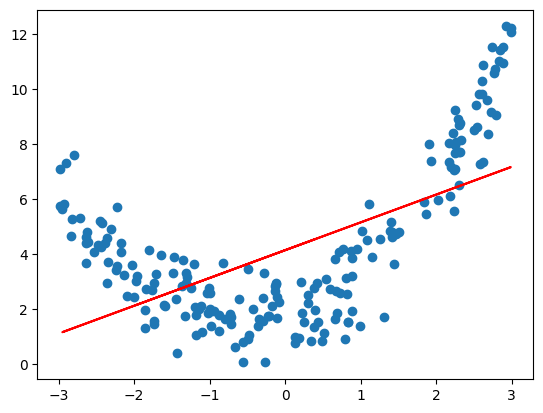

In [22]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.scatter(X,y)

In [24]:
poly=PolynomialFeatures(degree=2)
X_train_trans=poly.fit_transform(X_train)
X_test_trans=poly.transform(X_test)

In [25]:
print(X_train[0])
print(X_train_trans[0])

[-1.96958453]
[ 1.         -1.96958453  3.87926322]


In [26]:
lr=LinearRegression()
lr.fit(X_train_trans,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
y_pred=lr.predict(X_test_trans)

In [28]:
r2_score(y_test,y_pred)

0.9033189067670128

In [29]:
lr.coef_


array([[0.        , 0.79881746, 0.80098954]])

In [30]:
lr.intercept_

array([1.81495256])

In [36]:
X_new=poly.transform(X)
y_new=lr.predict(X_new)

In [43]:
sorted_idx = np.argsort(X_new.ravel())
X_new_sorted = X_new[sorted_idx]
y_new_sorted = y_new[sorted_idx]

IndexError: index 346 is out of bounds for axis 0 with size 200

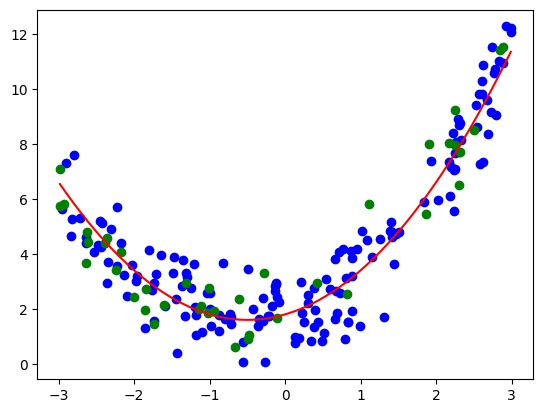

In [46]:
X_new = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_new = lr.predict(poly.transform(X_new))

plt.scatter(X_train, y_train, c='b')
plt.scatter(X_test, y_test, c='g')
plt.plot(X_new, y_new, 'r')

plt.show()
